# Hawkes 2-Point Function — Full Pipeline Demo

**Model:** Nonlinear Hawkes process, 2 populations, delta-function synaptic filters, quadratic nonlinearity

**Observable:** 2-point correlation function $\langle \delta\dot{n}_1(t_1)\, \delta\dot{n}_2(t_2) \rangle$

**Loop levels:** Tree-level ($\ell = 0$) and 1-loop ($\ell = 1$)

---

## What this notebook does

This notebook walks through the full automated Feynman diagram pipeline (Phases A–H) for a concrete MSRJD field theory.

### Section 1 — Theory / Model Information
Loads the 2-population nonlinear Hawkes model and prints all of its defining data: response fields ($\tilde{n}_i$), physical fluctuation fields ($\delta\dot{n}_i$), parameters, synaptic kernels, operators, and the nonlinear transfer function $\phi$. Then expands the MSRJD action to the required Taylor order and extracts the free-action kernel matrix $\mathbf{K}$, its Fourier transform $\hat{\mathbf{K}}(\omega)$, the retarded propagator $\hat{\mathbf{G}}(\omega) = \hat{\mathbf{K}}^{-1}(\omega)$, its poles, residue matrices, and the time-domain propagator $\mathbf{G}(t)$.

### Section 2 — Prediagram Enumeration
For the 2-point function ($k=2$), enumerates all labeled trees, undirected topologies, and directed prediagrams at tree level ($\ell=0$) and 1-loop ($\ell=1$). Plots each topology and prediagram with color-coded vertices: black = external legs, red = source vertices (noise insertions, in-degree 0), light blue = internal interaction vertices.

### Section 3 — Vertex Extraction
Reads off all interaction vertex types (`VertexType`) and noise source types (`SourceType`) from the expanded action. Each vertex type has a bigrade $(n_{\tilde{}}, n_{\text{phys}})$, a list of response and physical legs, and a coefficient. Checks that the current Taylor order is sufficient to cover the maximum vertex degree appearing in the prediagrams.

### Section 4 — Prediagram Filtering
Discards any prediagram whose internal vertex degree signatures don't match any available vertex or source type. Reports how many prediagrams survive at each loop level and plots the survivors.

### Section 5 — Type Assignment (Fully Labeled Diagrams)
Sets up the external fields for the 2-point function ($\delta\dot{n}_1$, $\delta\dot{n}_2$) and builds the field-to-matrix-index maps. Then runs the constraint-satisfaction engine on each surviving prediagram: for every valid assignment of vertex types to internal vertices and field types to edges (consistent with the propagator matrix $\hat{\mathbf{G}}$), it produces a `TypedDiagram`. Each typed diagram is printed showing its external leg assignments, vertex types with coefficients, and edge propagator labels $\hat{G}_{ij}$.

### Section 6 — Unique Diagrams & Combinatorial Factor $M(\Gamma)$
Deduplicates typed diagrams to obtain the set of unique Feynman diagrams $\Gamma$. For each unique diagram, computes the combinatorial factor $M(\Gamma)$ — the number of distinct valid leg-to-edge attachments (bijections) that realize $\Gamma$. An *attachment* assigns each leg slot of each vertex to a specific incident edge; identical legs (same field type) can be permuted freely, giving $M(\Gamma) = \prod_v \prod_{\text{groups of } k \text{ identical legs}} k!$. The diagram's contribution to the $k$-point function is $M(\Gamma) \times \prod_v \text{coeff}(v) \times \int(\text{propagators})$. Reference: Helias & Dahmen, *Statistical Field Theory for Neural Networks*, Ch. 9.

### Section 7 — Symbolic Integration (Stationary Case)
Constructs the frequency-domain integrand for representative diagrams: assigns frequency variables to edges, solves conservation constraints, and assembles the integrand as a product of propagator entries $\hat{G}_{ij}(\omega)$. Displays the unevaluated integral expression with the scalar prefactor factored out, then evaluates symbolically: tree-level diagrams reduce to algebraic expressions in the external frequency; one-loop diagrams are evaluated via the residue theorem.

In [1]:
%display latex
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))

from IPython.display import display, Math
from sage.all import (
    SR, matrix, latex, I, pi, exp, diff, solve, integrate, oo,
    dirac_delta, function, var
)

from msrjd.core.field_theory import FieldTheory, fourier_transform, inverse_fourier_transform
from msrjd.core.vertices import extract_vertex_types, extract_source_types, available_degrees
from msrjd.enumeration.loop_diagram_enumeration import enumerate_all
from msrjd.diagrams.filter import filter_prediagrams, classify_prediagram_vertices
from msrjd.diagrams.type_assignment import (
    enumerate_typed_diagrams, enumerate_all as enumerate_all_typed,
    build_field_index_map, TypedDiagram
)
from msrjd.diagrams.causality import filter_causal
from msrjd.diagrams.symmetry import (
    combinatorial_factor, compute_all_combinatorial_factors,
    deduplicate_typed_diagrams, classify_coefficient_factors,
)
from msrjd.integration.symbolic import (
    check_propagator_available, build_integrand_stationary,
    integrate_tree_level, integrate_one_loop_residues,
)

from models.hawkes_sage import HAWKES_MODEL

print('Imports loaded.')

Imports loaded.


---
## 1. Theory / Model Information

In [2]:
m = HAWKES_MODEL
print(f"Model:  {m['name']}")
print(f"Convention: {m['background_rate_convention']}")
print()

print('── Index sets ──')
for name, vals in m['index_sets'].items():
    print(f'  {name}: {list(vals)}')
print()

print('── Response fields (not expanded — full integration variables) ──')
for f in m['response_fields']:
    print(f"  {f['name']}  (latex: ${f.get('latex', f['name'])}$)  — {f.get('description', '')}")
print()

print('── Physical fields (expanded around MF background) ──')
for f in m['physical_fields']:
    print(f"  {f['name']}  (latex: ${f.get('latex', f['name'])}$)  — {f.get('description', '')}")
print()

print('── Parameters ──')
for p in m.get('parameters', []):
    idx = '(indexed)' if p.get('indexed') else '(scalar)'
    dom = f", domain={p['domain']}" if p.get('domain') else ''
    print(f"  {p['name']}  {idx}{dom}  — {p.get('description', '')}")
print()

print('── Kernels ──')
for k in m.get('kernels', []):
    print(f"  {k['name']}  — {k.get('description', '')}")
print()

print('── Operators ──')
for o in m.get('operators', []):
    print(f"  {o['name']}  (latex: ${o.get('latex_name', o['name'])}$)  — {o.get('description', '')}")
print()

print('── Nonlinear functions ──')
for f in m.get('functions', []):
    print(f"  {f['name']}  (latex: ${f.get('latex', f['name'])}$)  — {f.get('description', '')}")
print()

print('── Specializations ──')
print('  φ quadratic (cubic and higher coefficients = 0)')
print('  g = δ(t)  (instantaneous synaptic coupling)')

Model:  Nonlinear Hawkes 2-population
Convention: ṅ_i* = -φ_i(v_i*)  [positive Poisson term:  +ñ_i ṅ_i + (e^{ñ_i}-1) φ_i]

── Index sets ──
  pop: [0, 1]

── Response fields (not expanded — full integration variables) ──
  nt  (latex: $\tilde{n}$)  — response field conjugate to spike train
  vt  (latex: $\tilde{v}$)  — response field conjugate to voltage

── Physical fields (expanded around MF background) ──
  dn  (latex: $\delta\dot{n}$)  — spike-train fluctuation around MF background
  dv  (latex: $\delta v$)  — voltage fluctuation around MF background

── Parameters ──
  nstar  (indexed), domain=positive  — background firing rate  nstar_i = phi_i(vstar_i)
  vstar  (indexed)  — background voltage
  E  (indexed)  — external drive
  tau  (scalar), domain=positive  — membrane time constant

── Kernels ──
  g  — synaptic filter kernel g(t)

── Operators ──
  Dt  (latex: $\partial_t$)  — ∂_t  (algebraic placeholder for the time-derivative operator)

── Nonlinear functions ──
  phi  (latex

### 1.1 Expand the action and show all sectors

In [3]:
ft = FieldTheory(HAWKES_MODEL, taylor_order=4)
ft.expand()

R  = ft.ring()
ns = ft._ns

print(f'Taylor order: {ft.taylor_order}')
print(f'Polynomial ring: {R}')
print(f'Ring generators: {R.gens()}')
print(f'Response generators (n_tilde={ft._n_tilde}): {R.gens()[:ft._n_tilde]}')
print(f'Physical generators: {R.gens()[ft._n_tilde:]}')
print()

passed = ft.sanity_check()
print()
ft.summary()

Taylor order: 4
Polynomial ring: Multivariate Polynomial Ring in nt1, nt2, vt1, vt2, dn1, dn2, dv1, dv2 over Symbolic Ring
Ring generators: (nt1, nt2, vt1, vt2, dn1, dn2, dv1, dv2)
Response generators (n_tilde=4): (nt1, nt2, vt1, vt2)
Physical generators: (dn1, dn2, dv1, dv2)

=== Sanity checks ===
  [PASS]  (n_tilde=0, n_phys=0)  constant term
  [PASS]  (n_tilde=1, n_phys=0)  tadpole — must vanish at MF saddle
  [PASS]  (n_tilde=0, n_phys=1)  linear physical-only — must vanish at EOM

=== Action sectors ===
  (n_tilde=1, n_phys=1)  [free action]:


<IPython.core.display.Math object>

  (n_tilde=1, n_phys=2)  [vertex (order 3)]:


<IPython.core.display.Math object>

  (n_tilde=2, n_phys=0)  [noise kernel]:


...

<IPython.core.display.Math object>

  (n_tilde=4, n_phys=1)  [vertex (order 5)]:


<IPython.core.display.Math object>

  (n_tilde=4, n_phys=2)  [vertex (order 6)]:


<IPython.core.display.Math object>

### 1.2 Propagator

Extract the kernel matrix $\mathbf{K}$ from the free action, Fourier transform, and invert.

In [4]:
import signal

S_free = ft.free_action()
ring_gen_names = [str(g) for g in R.gens()]

resp_names = [f'vt{i+1}' for i in ns.pop] + [f'nt{i+1}' for i in ns.pop]
phys_names = [f'dv{i+1}' for i in ns.pop] + [f'dn{i+1}' for i in ns.pop]

pos_to_row = {ring_gen_names.index(nm): i for i, nm in enumerate(resp_names)}
pos_to_col = {ring_gen_names.index(nm): j for j, nm in enumerate(phys_names)}

nf = len(resp_names)
K_data = [[SR(0)] * nf for _ in range(nf)]
for exp_vec, coeff in S_free.dict().items():
    row = col = None
    for k in range(len(ring_gen_names)):
        if exp_vec[k] > 0:
            if k in pos_to_row: row = pos_to_row[k]
            if k in pos_to_col: col = pos_to_col[k]
    if row is not None and col is not None:
        K_data[row][col] += SR(coeff)

K_mat = matrix(SR, K_data)

# Convert to kernel form
Dt       = ns.Dt
delta_D  = ns.delta_D
delta_Dp = ns.delta_Dp

def _to_kernel(c):
    c = SR(c)
    if c.has(delta_D) or c.has(ns.g):
        return c
    p0   = c.subs({Dt: 0})
    rest = (c - p0).subs({Dt: delta_Dp})
    return p0 * delta_D + rest

K_ker = matrix(SR, [[_to_kernel(K_mat[i, j]) for j in range(nf)] for i in range(nf)])

resp_sr  = [ns.vt[i] for i in ns.pop] + [ns.nt[i] for i in ns.pop]
phys_sr  = [ns.dv[i] for i in ns.pop] + [ns.dn[i] for i in ns.pop]

print('Field ordering:')
display(Math(r'\tilde{\mathbf{a}} = ' + latex(vector(resp_sr))
             + r',\qquad \mathbf{a} = ' + latex(vector(phys_sr))))
print()
print('Kernel matrix K (time domain):')
display(Math(r'\mathbf{K} = ' + latex(K_ker)))

# Fourier transform
t_var = SR.var('t')
omega = SR.var('omega', latex_name=r'\omega')

time_domain = {
    delta_D:  dirac_delta(t_var),
    delta_Dp: diff(dirac_delta(t_var), t_var),
    ns.g:     function('g')(t_var),
}

K_ft_data = [[SR(0)] * nf for _ in range(nf)]
for i in range(nf):
    for j in range(nf):
        c = K_ker[i, j]
        if not c.is_zero():
            K_ft_data[i][j] = fourier_transform(SR(c).subs(time_domain), t_var, omega)

K_ft = matrix(SR, K_ft_data)
print('Fourier-domain kernel:')
display(Math(r'\hat{\mathbf{K}}(\omega) = ' + latex(K_ft)))

# Propagator inverse
G_ft = K_ft.inverse().apply_map(lambda e: e.factor())
G_ft_explicit = True
print('Propagator:')
display(Math(r'\hat{\mathbf{G}}(\omega) = ' + latex(G_ft)))

# Adjugate, determinant, poles
adj_ft  = K_ft.adjugate()
D_omega = K_ft.det().expand()
D_prime = diff(D_omega, omega)

pole_eqs = solve(D_omega == 0, omega)
pole_vals = [eq.rhs() if hasattr(eq, 'rhs') else eq for eq in pole_eqs]

print(f'\ndet(K̂) = {D_omega}')
print(f'Poles ({len(pole_vals)}):')
for k, p in enumerate(pole_vals):
    display(Math(r'\omega_{' + str(k+1) + '} = ' + latex(p)))

# Residue matrices
C_mats = []
for omega_k in pole_vals:
    C_data = [[SR(0)] * nf for _ in range(nf)]
    for i in range(nf):
        for j in range(nf):
            n_ij = adj_ft[i, j]
            if not n_ij.is_zero():
                num = n_ij.subs({omega: omega_k})
                den = D_prime.subs({omega: omega_k})
                C_data[i][j] = (I * num / den).factor()
    C_mats.append(matrix(SR, C_data))

print('Residue matrices:')
for k, C in enumerate(C_mats):
    display(Math(r'\mathbf{C}_{' + str(k+1) + r'} = ' + latex(C)))

# Time-domain propagator
G_t = sum(C_mats[k] * exp(I * pole_vals[k] * t_var) for k in range(len(pole_vals)))
G_t = G_t.apply_map(lambda e: e.simplify_full())
print('Time-domain propagator G(t) for t > 0:')
display(Math(r'\mathbf{G}(t) = ' + latex(G_t)))

Field ordering:


<IPython.core.display.Math object>


Kernel matrix K (time domain):


<IPython.core.display.Math object>

Fourier-domain kernel:


...

Residue matrices:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

Time-domain propagator G(t) for t > 0:


<IPython.core.display.Math object>

---
## 2. Prediagram Enumeration

Enumerate all trees, topologies, and prediagrams for the 2-point function at tree level ($\ell=0$) and 1-loop ($\ell=1$).

**Color code:** black = external legs, red = source vertices ($\mathrm{in}=0$), light blue = internal interaction vertices

In [5]:
from sage.plot.plot import graphics_array

def plot_prediagrams(pds, title_prefix=''):
    """Plot prediagrams with colored vertices."""
    if not pds:
        print('  (none)')
        return
    plots = []
    for i, (D, G, leaves, internal) in enumerate(pds):
        leaves_set = set(leaves)
        color_map = {}
        for v in D.vertices():
            if v in leaves_set:
                color_map.setdefault('black', []).append(v)
            elif D.in_degree(v) == 0:
                color_map.setdefault('red', []).append(v)
            else:
                color_map.setdefault('lightblue', []).append(v)
        plots.append(D.plot(vertex_colors=color_map, vertex_size=400,
                            edge_thickness=2, title=f"{title_prefix}{i+1}"))
    n_cols = min(4, len(plots))
    n_rows = (len(plots) + n_cols - 1) // n_cols
    graphics_array(plots, n_rows, n_cols).show(figsize=[5*n_cols, 4*n_rows])

def plot_topologies(topos, title_prefix=''):
    """Plot undirected topologies."""
    if not topos:
        print('  (none)')
        return
    plots = []
    for i, (G, leaves, internal) in enumerate(topos):
        leaves_set = set(leaves)
        color_map = {}
        for v in G.vertices():
            if v in leaves_set:
                color_map.setdefault('black', []).append(v)
            else:
                color_map.setdefault('lightgray', []).append(v)
        plots.append(G.plot(vertex_colors=color_map, vertex_size=400,
                            edge_thickness=2, title=f"{title_prefix}{i+1}"))
    n_cols = min(4, len(plots))
    n_rows = (len(plots) + n_cols - 1) // n_cols
    graphics_array(plots, n_rows, n_cols).show(figsize=[5*n_cols, 4*n_rows])

print('Plot helpers defined.')

Plot helpers defined.


### 2.1 Tree level ($\ell = 0$)

k=2, ell=0:  1 trees,  1 topologies,  1 prediagrams

── Trees ──
  Tree 1: 3 vertices, 2 edges, 2 leaves, j=0

── Topologies ──


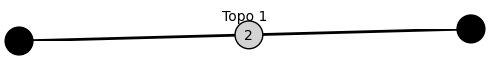

── Prediagrams ──


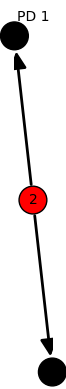

  PD 1: edges=[(2, 0), (2, 1)]
    v0: in=1, out=0 (leaf)
    v1: in=1, out=0 (leaf)
    v2: in=0, out=2 (source)


In [6]:
k = 2

trees_0, topos_0, pds_0, counts_0 = enumerate_all(k, 0, verbose=False)
print(f'k={k}, ell=0:  {counts_0["n_trees"]} trees,  {counts_0["n_topologies"]} topologies,  {counts_0["n_prediagrams"]} prediagrams')
print()

print('── Trees ──')
for i, (T, j, nl) in enumerate(trees_0):
    print(f'  Tree {i+1}: {T.num_verts()} vertices, {T.num_edges()} edges, {nl} leaves, j={j}')

print()
print('── Topologies ──')
plot_topologies(topos_0, title_prefix='Topo ')

print('── Prediagrams ──')
plot_prediagrams(pds_0, title_prefix='PD ')

for i, (D, G, leaves, internal) in enumerate(pds_0):
    print(f'  PD {i+1}: edges={D.edges(labels=False)}')
    for v in sorted(D.vertices()):
        role = 'leaf' if v in leaves else ('source' if D.in_degree(v)==0 else 'internal')
        print(f'    v{v}: in={D.in_degree(v)}, out={D.out_degree(v)} ({role})')

### 2.2 One loop ($\ell = 1$)

k=2, ell=1:  11 trees,  9 topologies,  9 prediagrams

── Topologies ──


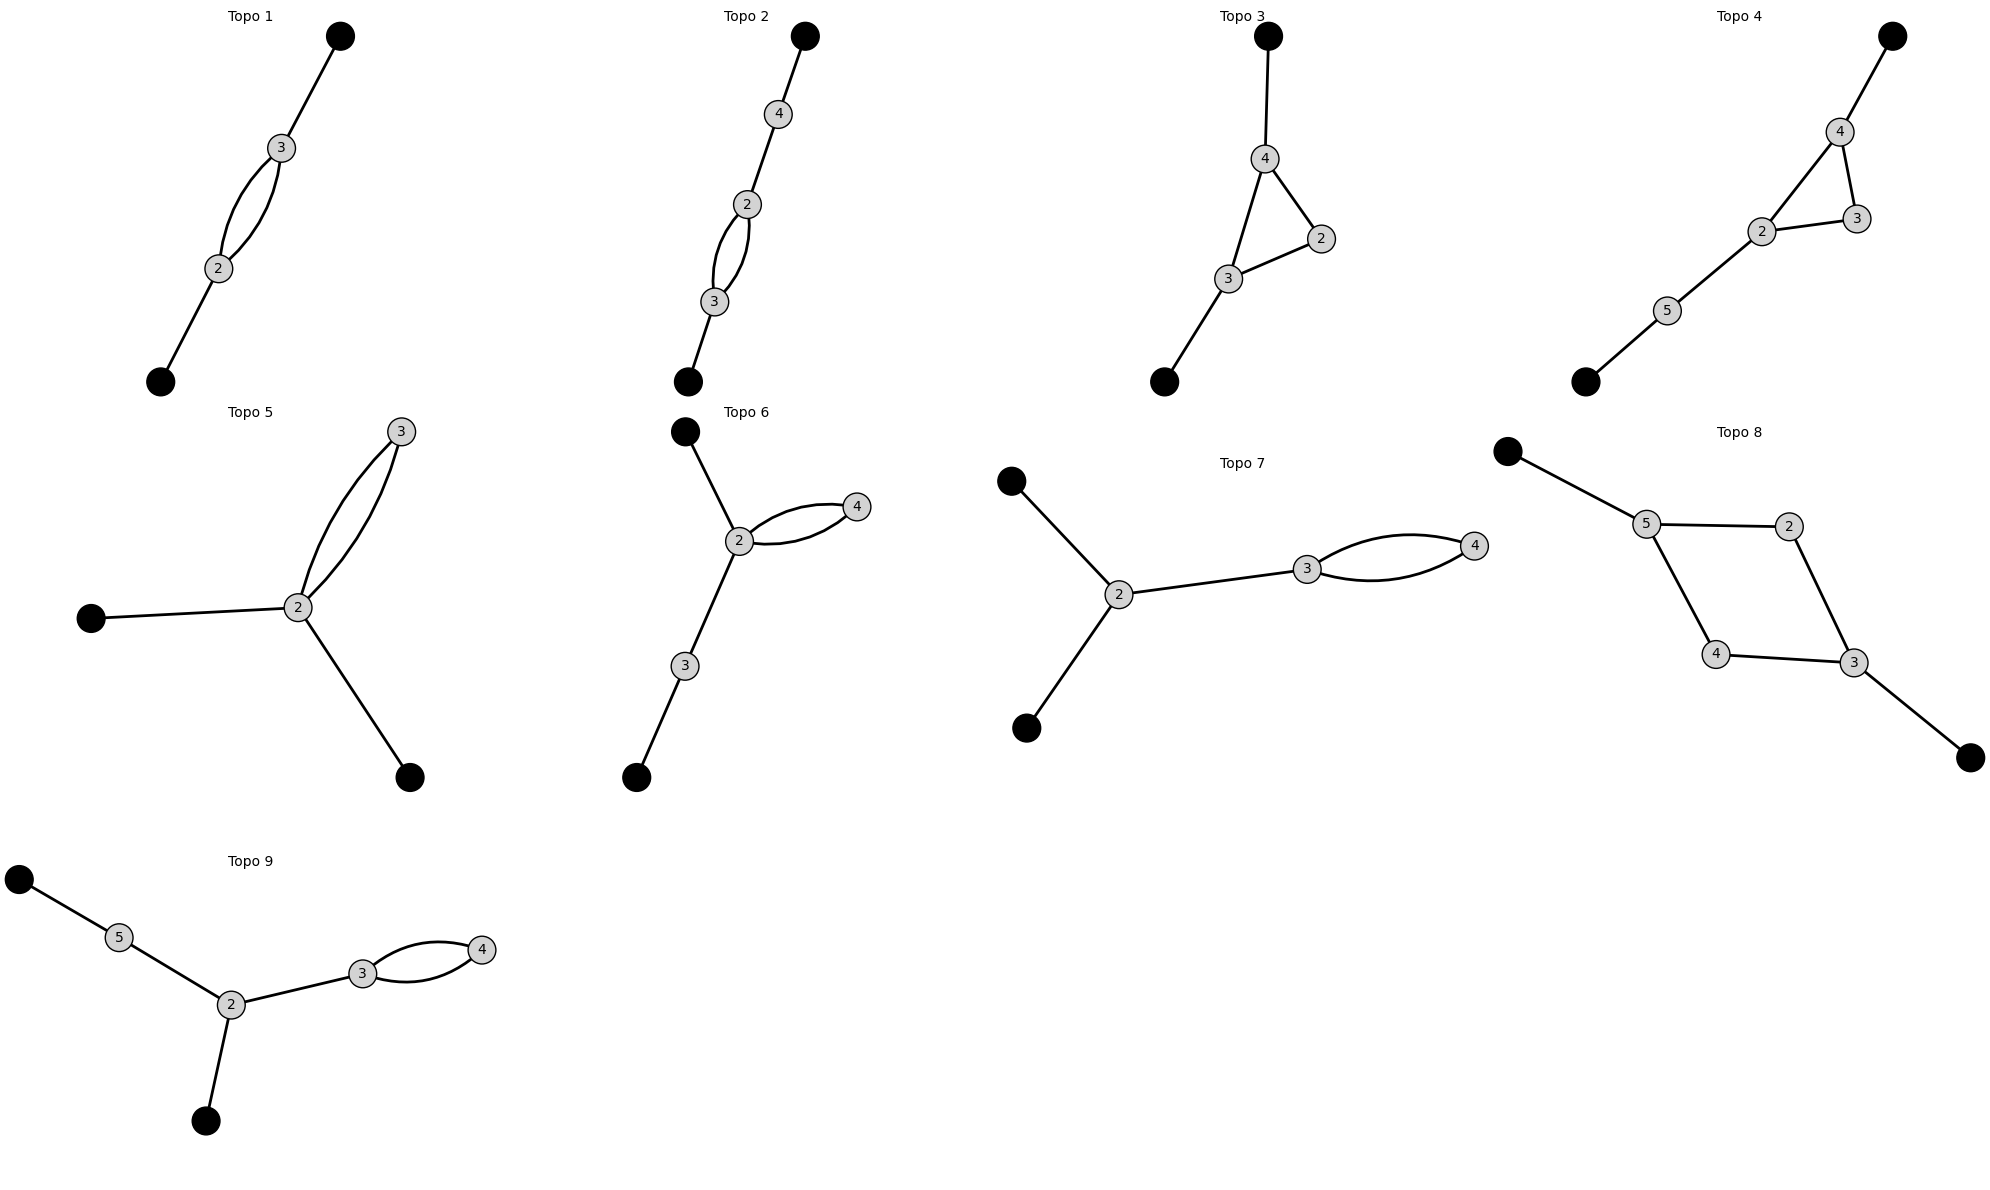

── Prediagrams ──


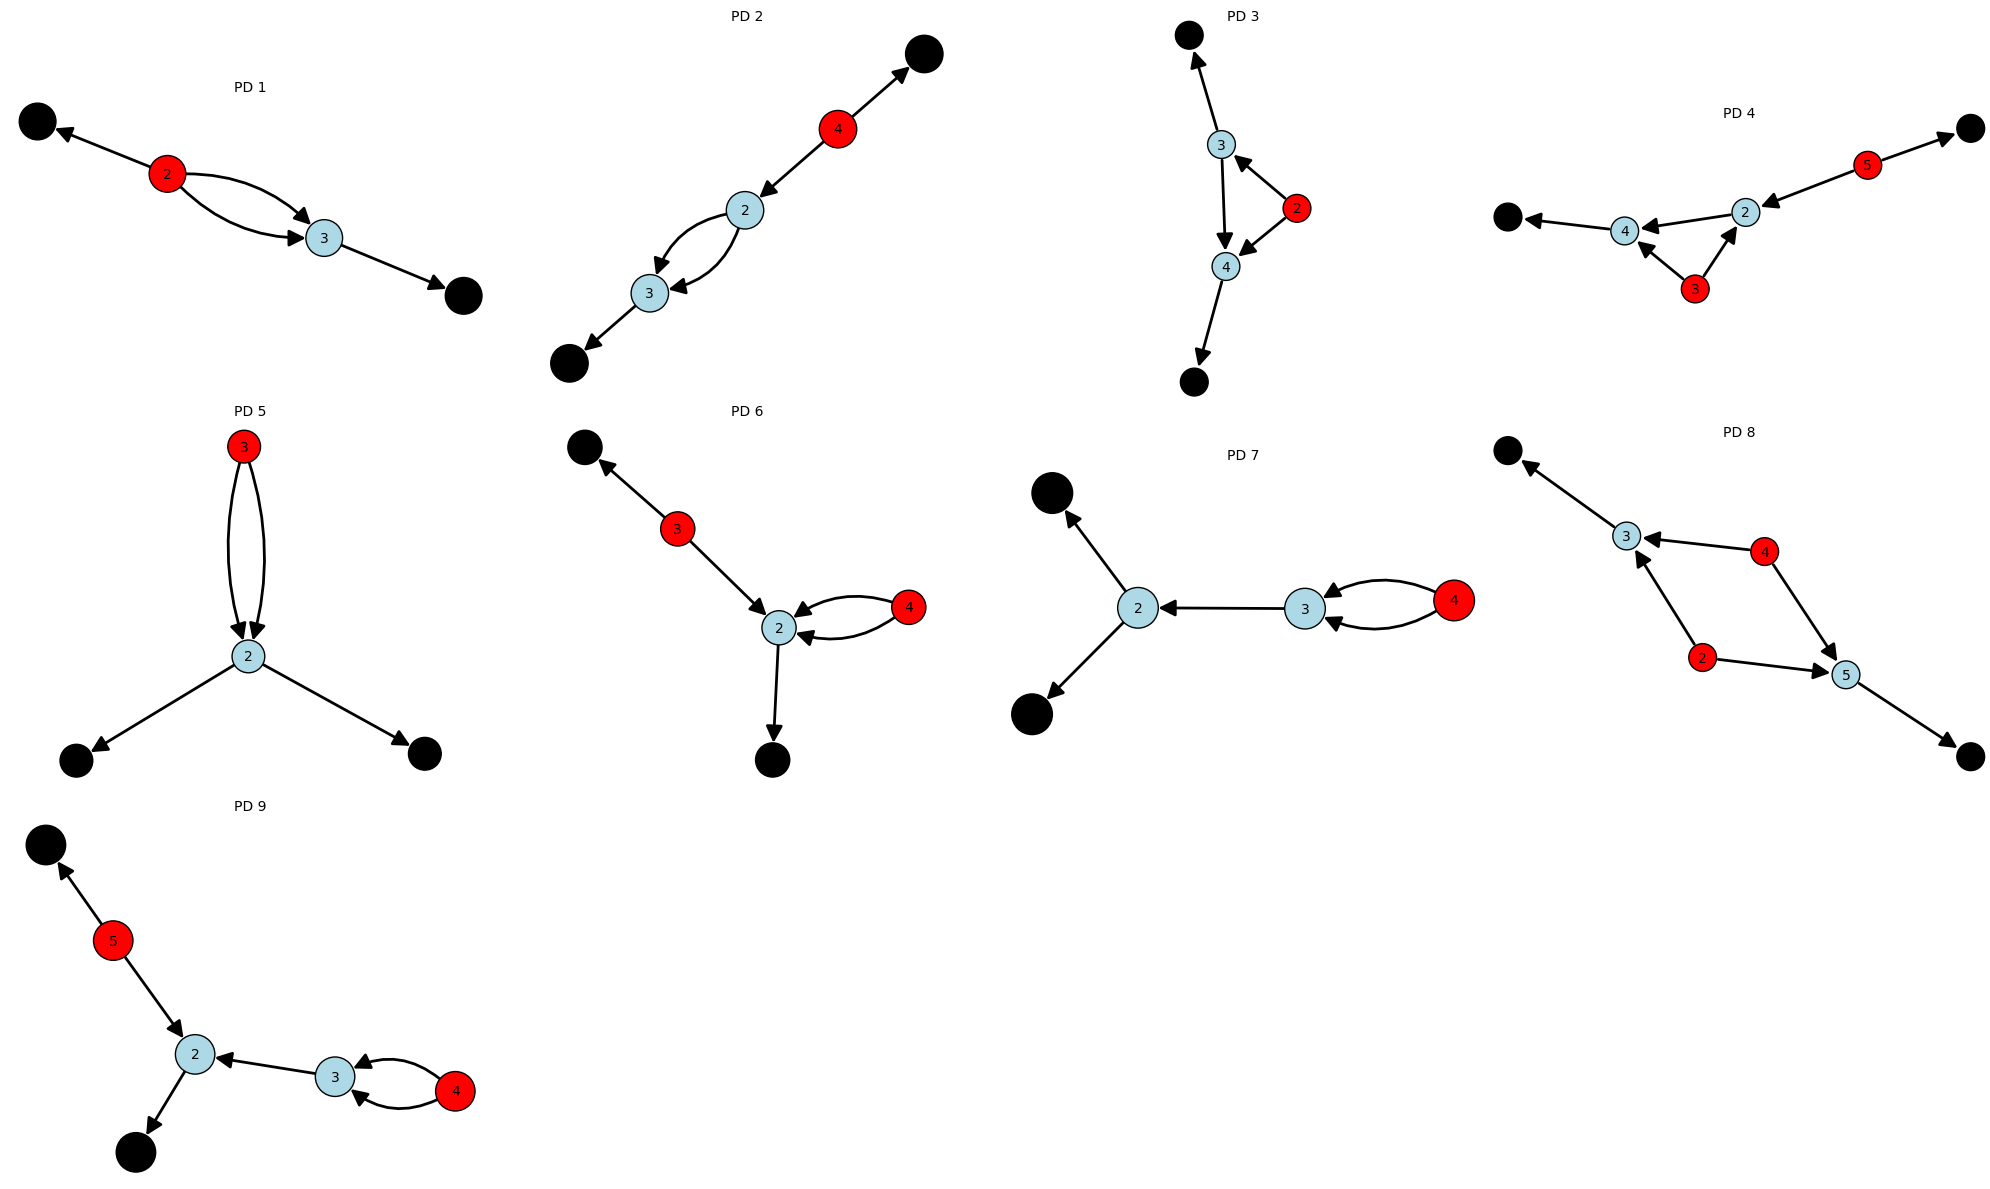

  PD 1: edges=[(2, 1), (2, 3), (2, 3), (3, 0)]
    v0: in=1, out=0 (leaf)
    v1: in=1, out=0 (leaf)
    v2: in=0, out=3 (source)
    v3: in=2, out=1 (internal)
  PD 2: edges=[(2, 3), (2, 3), (3, 0), (4, 1), (4, 2)]
    v0: in=1, out=0 (leaf)
    v1: in=1, out=0 (leaf)
    v2: in=1, out=2 (internal)
    v3: in=2, out=1 (internal)
    v4: in=0, out=2 (source)
  PD 3: edges=[(2, 3), (2, 4), (3, 0), (3, 4), (4, 1)]
    v0: in=1, out=0 (leaf)
    v1: in=1, out=0 (leaf)
    v2: in=0, out=2 (source)
    v3: in=1, out=2 (internal)
    v4: in=2, out=1 (internal)
  PD 4: edges=[(2, 4), (3, 2), (3, 4), (4, 0), (5, 1), (5, 2)]
    v0: in=1, out=0 (leaf)
    v1: in=1, out=0 (leaf)
    v2: in=2, out=1 (internal)
    v3: in=0, out=2 (source)
    v4: in=2, out=1 (internal)
    v5: in=0, out=2 (source)
  PD 5: edges=[(2, 0), (2, 1), (3, 2), (3, 2)]
    v0: in=1, out=0 (leaf)
    v1: in=1, out=0 (leaf)
    v2: in=2, out=2 (internal)
    v3: in=0, out=2 (source)
  PD 6: edges=[(2, 1), (3, 0), (3, 2), (4

In [7]:
trees_1, topos_1, pds_1, counts_1 = enumerate_all(k, 1, verbose=False)
print(f'k={k}, ell=1:  {counts_1["n_trees"]} trees,  {counts_1["n_topologies"]} topologies,  {counts_1["n_prediagrams"]} prediagrams')
print()

print('── Topologies ──')
plot_topologies(topos_1, title_prefix='Topo ')

print('── Prediagrams ──')
plot_prediagrams(pds_1, title_prefix='PD ')

for i, (D, G, leaves, internal) in enumerate(pds_1):
    print(f'  PD {i+1}: edges={D.edges(labels=False)}')
    for v in sorted(D.vertices()):
        role = 'leaf' if v in leaves else ('source' if D.in_degree(v)==0 else 'internal')
        print(f'    v{v}: in={D.in_degree(v)}, out={D.out_degree(v)} ({role})')

---
## 3. Vertex Extraction

Extract typed vertices (`VertexType`, `SourceType`) from the expanded action, based on the maximum vertex degree required by the prediagrams.

In [8]:
from msrjd.enumeration.degree_scan import max_vertex_degree, scan_source_vertices

all_pds = pds_0 + pds_1
max_deg = max_vertex_degree(all_pds)
src_degs = scan_source_vertices(all_pds)
print(f'Max vertex degree across all prediagrams: {max_deg}')
print(f'Source vertex out-degrees needed: {src_degs}')
print(f'Current Taylor order: {ft.taylor_order}')
print(f'Sufficient: {ft.taylor_order >= max_deg}')
print()

vtypes = extract_vertex_types(ft)
stypes = extract_source_types(ft)

print(f'── Interaction vertex types ({len(vtypes)}) ──')
for i, vt in enumerate(vtypes):
    print(f'  V{i+1}: bigrade={vt.bigrade}, in_deg={vt.in_degree}, out_deg={vt.out_degree}')
    print(f'        resp_legs={vt.response_legs}, phys_legs={vt.physical_legs}')
    display(Math(f'\\quad\\text{{coeff}} = {latex(vt.coefficient)}'))

print(f'\n── Source types ({len(stypes)}) ──')
for i, st in enumerate(stypes):
    print(f'  S{i+1}: bigrade={st.bigrade}, out_deg={st.out_degree}')
    print(f'        resp_legs={st.response_legs}')
    display(Math(f'\\quad\\text{{coeff}} = {latex(st.coefficient)}'))

int_degs, src_degs_avail = available_degrees(vtypes, stypes)
print(f'\nAvailable interaction degrees (in, out): {sorted(int_degs)}')
print(f'Available source out-degrees: {sorted(src_degs_avail)}')

Max vertex degree across all prediagrams: 4
Source vertex out-degrees needed: {2, 3}
Current Taylor order: 4
Sufficient: True

── Interaction vertex types (14) ──
  V1: bigrade=(4, 2), in_deg=2, out_deg=4
        resp_legs=[('nt', 1), ('nt', 1), ('nt', 1), ('nt', 1)], phys_legs=[('dv', 1), ('dv', 1)]


<IPython.core.display.Math object>

  V2: bigrade=(4, 2), in_deg=2, out_deg=4
        resp_legs=[('nt', 2), ('nt', 2), ('nt', 2), ('nt', 2)], phys_legs=[('dv', 2), ('dv', 2)]


<IPython.core.display.Math object>

  V3: bigrade=(4, 1), in_deg=1, out_deg=4
        resp_legs=[('nt', 1), ('nt', 1), ('nt', 1), ('nt', 1)], phys_legs=[('dv', 1)]


...

  S5: bigrade=(2, 0), out_deg=2
        resp_legs=[('nt', 1), ('nt', 1)]


<IPython.core.display.Math object>

  S6: bigrade=(2, 0), out_deg=2
        resp_legs=[('nt', 2), ('nt', 2)]


<IPython.core.display.Math object>


Available interaction degrees (in, out): [(1, 2), (1, 3), (1, 4), (2, 1), (2, 2), (2, 3), (2, 4)]
Available source out-degrees: [2, 3, 4]


---
## 4. Prediagram Filtering

Remove prediagrams whose vertex degree signatures don't match any available vertex or source type.

── Tree level (ell=0) ──
  1 prediagrams → 1 kept, 0 discarded

── 1-loop (ell=1) ──
  9 prediagrams → 8 kept, 1 discarded

  Discarded prediagram indices:
    PD 6: internal vertex degrees = [(3, 1), (0, 2), (0, 2)]

── Surviving prediagrams (tree level) ──


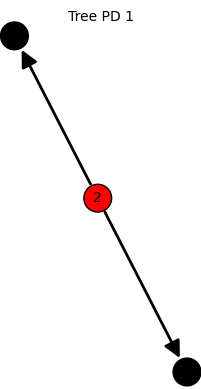

── Surviving prediagrams (1-loop) ──


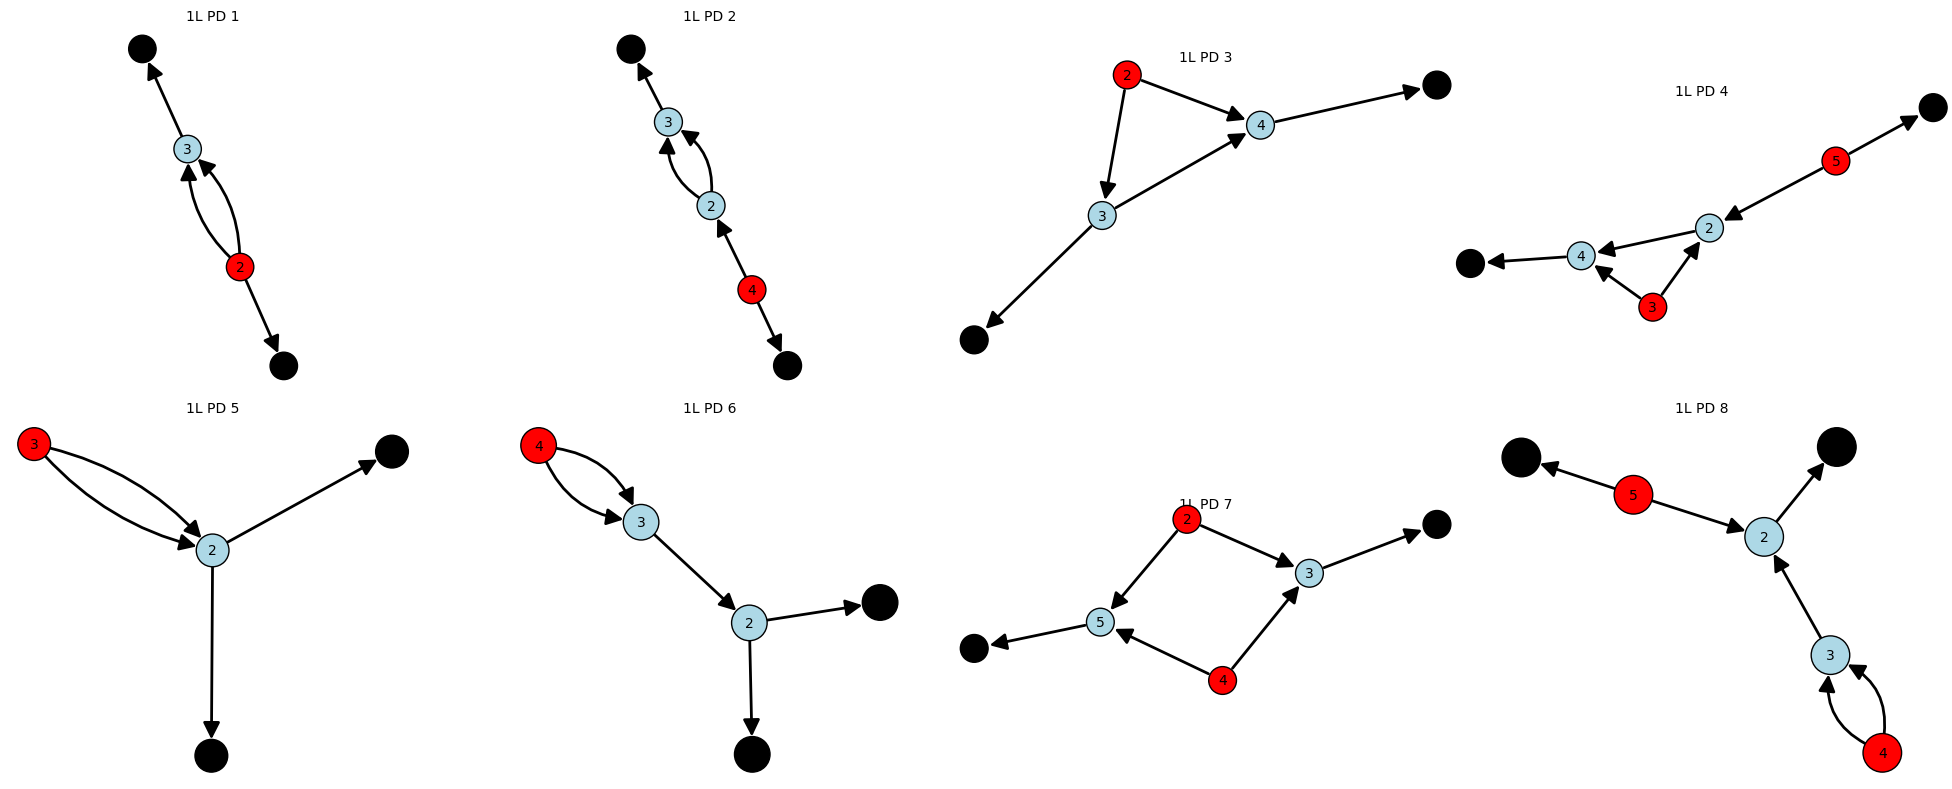

In [9]:
print('── Tree level (ell=0) ──')
kept_0, disc_0 = filter_prediagrams(pds_0, vtypes, stypes)
print(f'  {len(pds_0)} prediagrams → {len(kept_0)} kept, {disc_0} discarded')

print()
print('── 1-loop (ell=1) ──')
kept_1, disc_1 = filter_prediagrams(pds_1, vtypes, stypes)
print(f'  {len(pds_1)} prediagrams → {len(kept_1)} kept, {disc_1} discarded')

if disc_1 > 0:
    print(f'\n  Discarded prediagram indices:')
    kept_set = set(id(p) for p in kept_1)
    for i, pd in enumerate(pds_1):
        if id(pd) not in kept_set:
            D = pd[0]
            degs = [(D.in_degree(v), D.out_degree(v)) for v in pd[3]]  # internal verts
            print(f'    PD {i+1}: internal vertex degrees = {degs}')

print()
print('── Surviving prediagrams (tree level) ──')
plot_prediagrams(kept_0, title_prefix='Tree PD ')

print('── Surviving prediagrams (1-loop) ──')
plot_prediagrams(kept_1, title_prefix='1L PD ')

---
## 5. Type Assignment — Fully Labeled Diagrams

Enumerate all valid field-type assignments on each surviving prediagram.

**External legs:** $\delta\dot{n}_1$ and $\delta\dot{n}_2$ (the 2-point function fields).  
**Edge convention:** each directed edge $u \to v$ carries propagator $\hat{G}_{ij}(\omega)$ where $i$ is a response-field index from $u$ and $j$ is a physical-field index from $v$.

In [10]:
# External fields for the 2-point function <dn1 dn2>
# dn1, dn2 are physical fields — they sit at the incoming-edge end of leaves
external_fields = [('dn', 1), ('dn', 2)]

# Build field index maps
ring_var_names_list = list(ns._ring_var_names)
n_tilde = ft._n_tilde
resp_idx, phys_idx = build_field_index_map(ring_var_names_list, n_tilde)

print('Response field index map:')
for leg, idx in sorted(resp_idx.items(), key=lambda x: x[1]):
    print(f'  {leg} → row {idx}')
print()
print('Physical field index map:')
for leg, idx in sorted(phys_idx.items(), key=lambda x: x[1]):
    print(f'  {leg} → col {idx}')

# Helper to display typed diagrams nicely
def show_typed_diagram(td, idx):
    D = td.prediagram[0]
    leaves = td.prediagram[2]
    print(f'\n{"="*60}')
    print(f'Diagram {idx}')
    print(f'{"="*60}')
    
    print('  External legs:')
    for lf, field in sorted(td.external_legs.items()):
        print(f'    leaf {lf} ← {field[0]}{field[1]}')
    
    if td.vertex_assignments:
        print('  Vertex assignments:')
        for v, vtype in sorted(td.vertex_assignments.items()):
            tname = type(vtype).__name__
            print(f'    v{v} ({tname}): bigrade={vtype.bigrade}, '
                  f'resp={vtype.response_legs}', end='')
            if hasattr(vtype, 'physical_legs'):
                print(f', phys={vtype.physical_legs}', end='')
            print()
            display(Math(f'\\quad\\text{{coeff}} = {latex(vtype.coefficient)}'))
    
    print('  Edges (propagator assignments):')
    for (u, v), (resp_leg, phys_leg) in sorted(td.edge_types.items()):
        ri, pi = td.propagator_indices.get((u, v), ('?', '?'))
        print(f'    {u} → {v}:  {resp_leg[0]}{resp_leg[1]} → {phys_leg[0]}{phys_leg[1]}  '
              f'[G_hat[{ri},{pi}]]')

Response field index map:
  ('nt', 1) → row 0
  ('nt', 2) → row 1
  ('vt', 1) → row 2
  ('vt', 2) → row 3

Physical field index map:
  ('dn', 1) → col 0
  ('dn', 2) → col 1
  ('dv', 1) → col 2
  ('dv', 2) → col 3


### 5.1 Tree-level typed diagrams

In [11]:
typed_tree = enumerate_all_typed(
    kept_0, external_fields, vtypes, stypes, G_ft, resp_idx, phys_idx
)
print(f'Tree-level: {len(kept_0)} prediagrams → {len(typed_tree)} typed diagrams')

for i, td in enumerate(typed_tree, 1):
    show_typed_diagram(td, f'Tree-{i}')

Tree-level: 1 prediagrams → 8 typed diagrams

Diagram Tree-1
  External legs:
    leaf 0 ← dn1
    leaf 1 ← dn2
  Vertex assignments:
    v2 (SourceType): bigrade=(2, 0), resp=[('nt', 1), ('nt', 1)]


<IPython.core.display.Math object>

  Edges (propagator assignments):
    2 → 0:  nt1 → dn1  [G_hat[0,0]]
    2 → 1:  nt1 → dn2  [G_hat[0,1]]

Diagram Tree-2
  External legs:
    leaf 0 ← dn1
    leaf 1 ← dn2
  Vertex assignments:
    v2 (SourceType): bigrade=(2, 0), resp=[('nt', 1), ('nt', 1)]


<IPython.core.display.Math object>

  Edges (propagator assignments):
    2 → 0:  nt1 → dn1  [G_hat[0,0]]
    2 → 1:  nt1 → dn2  [G_hat[0,1]]

Diagram Tree-3
  External legs:
    leaf 0 ← dn1
    leaf 1 ← dn2
  Vertex assignments:
    v2 (SourceType): bigrade=(2, 0), resp=[('nt', 2), ('nt', 2)]


...

  Edges (propagator assignments):
    2 → 0:  nt1 → dn2  [G_hat[0,1]]
    2 → 1:  nt1 → dn1  [G_hat[0,0]]

Diagram Tree-7
  External legs:
    leaf 0 ← dn2
    leaf 1 ← dn1
  Vertex assignments:
    v2 (SourceType): bigrade=(2, 0), resp=[('nt', 2), ('nt', 2)]


<IPython.core.display.Math object>

  Edges (propagator assignments):
    2 → 0:  nt2 → dn2  [G_hat[1,1]]
    2 → 1:  nt2 → dn1  [G_hat[1,0]]

Diagram Tree-8
  External legs:
    leaf 0 ← dn2
    leaf 1 ← dn1
  Vertex assignments:
    v2 (SourceType): bigrade=(2, 0), resp=[('nt', 2), ('nt', 2)]


<IPython.core.display.Math object>

  Edges (propagator assignments):
    2 → 0:  nt2 → dn2  [G_hat[1,1]]
    2 → 1:  nt2 → dn1  [G_hat[1,0]]


### 5.2 One-loop typed diagrams

In [12]:
typed_1loop = enumerate_all_typed(
    kept_1, external_fields, vtypes, stypes, G_ft, resp_idx, phys_idx
)
print(f'1-loop: {len(kept_1)} prediagrams → {len(typed_1loop)} typed diagrams')

for i, td in enumerate(typed_1loop, 1):
    show_typed_diagram(td, f'1L-{i}')

1-loop: 8 prediagrams → 1152 typed diagrams

Diagram 1L-1
  External legs:
    leaf 0 ← dn1
    leaf 1 ← dn2
  Vertex assignments:
    v2 (SourceType): bigrade=(2, 0), resp=[('nt', 1), ('nt', 1)]


<IPython.core.display.Math object>

    v3 (VertexType): bigrade=(2, 1), resp=[('nt', 1), ('nt', 1)], phys=[('dv', 1)]


<IPython.core.display.Math object>

    v4 (VertexType): bigrade=(1, 2), resp=[('nt', 1)], phys=[('dv', 1), ('dv', 1)]


...

    v4 (SourceType): bigrade=(2, 0), resp=[('nt', 2), ('nt', 2)]


<IPython.core.display.Math object>

    v5 (VertexType): bigrade=(1, 2), resp=[('nt', 2)], phys=[('dv', 2), ('dv', 2)]


<IPython.core.display.Math object>

  Edges (propagator assignments):
    2 → 3:  nt2 → dv2  [G_hat[1,3]]
    2 → 5:  nt2 → dv2  [G_hat[1,3]]
    3 → 0:  nt2 → dn2  [G_hat[1,1]]
    4 → 3:  nt2 → dv2  [G_hat[1,3]]
    4 → 5:  nt2 → dv2  [G_hat[1,3]]
    5 → 1:  nt2 → dn1  [G_hat[1,0]]


---
## 6. Unique Diagrams & Combinatorial Factor $M(\Gamma)$

Deduplicate typed diagrams to obtain the set of unique Feynman diagrams $\Gamma$. For each, compute the **combinatorial factor**

$$M(\Gamma) = \prod_{v} \prod_{\substack{\text{groups of } k \\ \text{identical legs at } v}} k!$$

### What can be pulled outside the integral?

| Factor | Outside integral? | Condition |
|--------|------------------|-----------|
| $M(\Gamma)$ | **Always** | It's a pure integer |
| Interaction vertex $c_v$ | Only if constant | No symbols in `time_dep_params` |
| Source amplitude $c_{\text{src}}$ | Only if white noise AND constant amplitude | $\kappa = c \cdot \delta(t_1 - t_2)$ with $c$ not time-dependent |
| Source kernel $\kappa(t_1, t_2)$ | Never (for colored/general noise) | Enters integrand as $\hat{\kappa}(\omega)$ or $\kappa(t_1, t_2)$ |

### Stationarity vs factorizability

**Stationary** means all time dependencies are through time *differences* only — the system is Fourier-transformable. This is true for both white noise ($\kappa \propto \delta(\tau)$) and colored noise ($\kappa(\tau)$). But colored noise is stationary yet its kernel $\hat{\kappa}(\omega)$ **still enters the frequency integral** — it cannot be pulled out as a scalar.

### General weight formula

$$\text{weight}(\Gamma) = M(\Gamma) \times \int \prod_{v \in \text{int}} dt_v\; c_v(t_v) \times \prod_{\text{src}} \kappa(t_1, \ldots, t_k) \times \prod_{e=(u \to v)} G_{ij}(t_u, t_v)$$

The current Hawkes model has stationary white noise with constant amplitude, so all factors come outside. (Ref: Helias & Dahmen, Ch. 9.)

In [13]:
# Get time-dependence metadata from the model
time_dep_params = HAWKES_MODEL.get('time_dependent_parameters', [])
noise_structure = HAWKES_MODEL.get('noise_structure', {
    'temporal_type': 'white', 'amplitude_params': []
})
print(f'Noise temporal type: {noise_structure.get("temporal_type", "white")}')
print(f'Noise amplitude params: {noise_structure.get("amplitude_params", [])}')
print(f'Time-dependent params: {time_dep_params if time_dep_params else "(none — stationary)"}')
print()


def show_unique_diagram(td, idx, winfo):
    """Display a unique diagram with M(Gamma) and weight structure."""
    M = winfo['M']
    print(f'\n{"="*60}')
    print(f'Unique Diagram {idx}')
    print(f'{"="*60}')

    # Combinatorial factor
    display(Math(f'M(\\Gamma) = {M}'))

    print('  External legs:')
    for lf, field in sorted(td.external_legs.items()):
        print(f'    leaf {lf} <- {field[0]}{field[1]}')

    if td.vertex_assignments:
        print('  Vertex assignments:')
        for v, vtype in sorted(td.vertex_assignments.items()):
            tname = type(vtype).__name__
            n_legs = len(vtype.response_legs)

            if tname == 'SourceType':
                sinfo = winfo['source_time_info'].get(v, {})
                nt = sinfo.get('temporal_type', 'white')
                in_int = sinfo.get('in_integrand', False)
                print(f'    v{v} (Source): bigrade={vtype.bigrade}, '
                      f'resp={vtype.response_legs}, '
                      f'noise={nt}, {n_legs} leg-time(s)'
                      f'{", IN INTEGRAND" if in_int else ", scalar"}')
            else:
                in_int = v in winfo['vertex_time_factors']
                print(f'    v{v} (Interaction): bigrade={vtype.bigrade}, '
                      f'resp={vtype.response_legs}', end='')
                if hasattr(vtype, 'physical_legs'):
                    print(f', phys={vtype.physical_legs}', end='')
                print(f', 1 vertex-time'
                      f'{", IN INTEGRAND" if in_int else ", scalar"}')

            display(Math(f'\\quad c_{{v_{v}}} = {latex(vtype.coefficient)}'))

    print('  Edges (propagator assignments):')
    for (u, v), (resp_leg, phys_leg) in sorted(td.edge_types.items()):
        ri, pi = td.propagator_indices.get((u, v), ('?', '?'))
        print(f'    {u} -> {v}:  {resp_leg[0]}{resp_leg[1]} -> {phys_leg[0]}{phys_leg[1]}  '
              f'[G_hat[{ri},{pi}]]')

    # Weight structure
    sp = winfo['scalar_prefactor']
    display(Math(
        r'\text{Scalar prefactor (outside integral): }\;'
        + latex(sp)
    ))

    if winfo['vertex_time_factors']:
        for v, td_factor in sorted(winfo['vertex_time_factors'].items()):
            display(Math(
                f'\\text{{Interaction v}}{v}'
                f'\\text{{ time-dep factor (inside integral): }}'
                f'{latex(td_factor)}'
            ))
    for v, sinfo in sorted(winfo['source_time_info'].items()):
        if sinfo['in_integrand']:
            n = sinfo['n_legs']
            t_args = ', '.join(f't_{{{v},{k+1}}}' for k in range(n))
            label = sinfo['temporal_type']
            if sinfo['amplitude_is_time_dep']:
                label += ', time-dep amplitude'
            display(Math(
                f'\\text{{Source v}}{v}'
                f'\\text{{ kernel (inside integral): }}'
                f'\\kappa({t_args})'
                f'\\quad[\\text{{{label}}}]'
            ))

    print(f'  Stationary (Fourier-transformable): '
          f'{"yes" if winfo["is_stationary"] else "no"}')


# ── Tree level ──
print('='*60)
print('TREE-LEVEL UNIQUE DIAGRAMS')
print('='*60)

unique_tree = deduplicate_typed_diagrams(typed_tree)
print(f'{len(typed_tree)} typed diagrams -> {len(unique_tree)} unique diagrams')

for i, td in enumerate(unique_tree, 1):
    winfo = classify_coefficient_factors(td, time_dep_params, noise_structure)
    show_unique_diagram(td, f'Tree-{i}', winfo)


# ── 1-loop ──
print('\n')
print('='*60)
print('1-LOOP UNIQUE DIAGRAMS')
print('='*60)

unique_1loop = deduplicate_typed_diagrams(typed_1loop)
print(f'{len(typed_1loop)} typed diagrams -> {len(unique_1loop)} unique diagrams')

for i, td in enumerate(unique_1loop, 1):
    winfo = classify_coefficient_factors(td, time_dep_params, noise_structure)
    show_unique_diagram(td, f'1L-{i}', winfo)

Noise temporal type: white
Noise amplitude params: ['nstar']
Time-dependent params: (none — stationary)

TREE-LEVEL UNIQUE DIAGRAMS
8 typed diagrams -> 4 unique diagrams

Unique Diagram Tree-1


<IPython.core.display.Math object>

  External legs:
    leaf 0 <- dn1
    leaf 1 <- dn2
  Vertex assignments:
    v2 (Source): bigrade=(2, 0), resp=[('nt', 1), ('nt', 1)], noise=white, 2 leg-time(s), scalar


<IPython.core.display.Math object>

  Edges (propagator assignments):
    2 -> 0:  nt1 -> dn1  [G_hat[0,0]]
    2 -> 1:  nt1 -> dn2  [G_hat[0,1]]


...

    v5 (Interaction): bigrade=(1, 2), resp=[('nt', 2)], phys=[('dv', 2), ('dv', 2)], 1 vertex-time, scalar


<IPython.core.display.Math object>

  Edges (propagator assignments):
    2 -> 3:  nt2 -> dv2  [G_hat[1,3]]
    2 -> 5:  nt2 -> dv2  [G_hat[1,3]]
    3 -> 0:  nt2 -> dn2  [G_hat[1,1]]
    4 -> 3:  nt2 -> dv2  [G_hat[1,3]]
    4 -> 5:  nt2 -> dv2  [G_hat[1,3]]
    5 -> 1:  nt2 -> dn1  [G_hat[1,0]]


<IPython.core.display.Math object>

  Stationary (Fourier-transformable): yes


---
## 7. Symbolic Integration (Stationary Case)

For each unique diagram $\Gamma$, construct the frequency-domain integrand and evaluate symbolically.

**Tree level ($\ell = 0$):** No integral.  All edge frequencies are fixed by conservation.  The contribution is:
$$\text{weight}(\Gamma) = \underbrace{M(\Gamma) \times \prod_v c_v}_{\text{scalar prefactor}} \times \prod_e \hat{G}_{i_e, j_e}(\omega_{\text{ext}})$$

**One loop ($\ell = 1$):** A single frequency integral evaluated via residues:
$$\text{weight}(\Gamma) = \underbrace{M(\Gamma) \times \prod_v c_v}_{\text{scalar prefactor}} \times \frac{1}{2\pi} \int_{-\infty}^{\infty} d\Omega \; \prod_e \hat{G}_{i_e, j_e}\!\big(\omega_e(\Omega, \omega_{\text{ext}})\big)$$

We show one representative diagram from each loop level: the unevaluated symbolic integral expression, then the compact result after integration.

In [14]:
# ── Propagator data dict (assembled from Section 1.2) ──
omega = SR.var('omega', latex_name=r'\omega')

propagator_data = {
    'G_ft': G_ft,
    'adj_ft': adj_ft,
    'D_omega': D_omega,
    'G_ft_explicit': True,
    'pole_vals': pole_vals,
    'C_mats': C_mats,
    'nf': nf,
}

prop_mode = check_propagator_available(propagator_data)
print(f'Propagator mode: {prop_mode}')
print(f'Poles: {pole_vals}')
print()

# ── Helper to display a diagram's integral expression ──

def show_integration(td, label, propagator_data, omega_sym, loop_level):
    """
    For a single typed diagram, display:
      1. The unevaluated integral expression
      2. The compact evaluated result
    """
    print(f'\n{"="*60}')
    print(f'Diagram: {label}   (loop level {loop_level})')
    print(f'{"="*60}')

    # Build the full integrand assembly
    ir = build_integrand_stationary(
        td, propagator_data, k=2,
        omega_symbol=omega_sym,
        time_dep_params=HAWKES_MODEL.get('time_dependent_parameters', []),
        noise_structure=HAWKES_MODEL.get('noise_structure'),
    )

    prefactor = ir['scalar_prefactor']
    integrand = ir['integrand']
    loop_freqs = ir['loop_freqs']
    ext_freqs = ir['ext_freqs']
    ell = ir['loop_number']
    overall = ir['overall_conservation']

    # Show external frequency info
    print(f'  External frequencies: {ext_freqs}')
    if overall is not None:
        display(Math(
            r'\text{Overall conservation: }\;'
            + latex(overall) + r' = 0'
        ))

    # Show edge frequency assignments
    print(f'  Edge frequency solutions:')
    for ekey, omega_e in sorted(ir['edge_freqs'].items(), key=str):
        resolved = omega_e.subs(ir['freq_substitutions'])
        print(f'    {ekey}: {omega_e} = {resolved}')

    print()

    # ── Display the unevaluated expression ──
    prefactor_tex = latex(prefactor)
    integrand_tex = latex(integrand)

    if ell == 0:
        # Tree level: no integral
        display(Math(
            r'\text{weight}(\Gamma) = '
            + prefactor_tex
            + r' \times '
            + integrand_tex
        ))
    elif ell == 1:
        Omega_tex = latex(loop_freqs[0])
        display(Math(
            r'\text{weight}(\Gamma) = '
            + prefactor_tex
            + r' \times \frac{1}{2\pi}'
            + r' \int_{-\infty}^{\infty} d' + Omega_tex
            + r' \; '
            + integrand_tex
        ))
    else:
        Omega_texs = [latex(lf) for lf in loop_freqs]
        integrals = ''.join(
            r'\int_{-\infty}^{\infty} d' + ot + r'\;'
            for ot in Omega_texs
        )
        display(Math(
            r'\text{weight}(\Gamma) = '
            + prefactor_tex
            + r' \times \frac{1}{(2\pi)^{' + str(ell) + r'}}'
            + integrals
            + integrand_tex
        ))

    # ── Evaluate ──
    print()
    if ell == 0:
        result = integrate_tree_level(ir)
        # Apply overall conservation to reduce to one ext freq
        if overall is not None and len(ext_freqs) >= 2:
            # Solve the conservation relation for the second ext freq
            from sage.all import solve as sage_solve
            cons_sol = sage_solve(overall == 0, ext_freqs[1], solution_dict=True)
            if cons_sol:
                result = result.subs(cons_sol[0])
                print(f'  (Applied overall conservation: {ext_freqs[1]} = {cons_sol[0][ext_freqs[1]]})')

        try:
            result = result.factor()
        except Exception:
            pass
        print('  Evaluated (tree):')
        display(Math(
            r'\text{weight}(\Gamma) = '
            + latex(result)
        ))

    elif ell == 1:
        try:
            result = integrate_one_loop_residues(
                ir, pole_vals, omega_symbol=omega_sym
            )
            # Apply overall conservation
            if overall is not None and len(ext_freqs) >= 2:
                from sage.all import solve as sage_solve
                cons_sol = sage_solve(overall == 0, ext_freqs[1], solution_dict=True)
                if cons_sol:
                    result = result.subs(cons_sol[0])
                    print(f'  (Applied overall conservation: {ext_freqs[1]} = {cons_sol[0][ext_freqs[1]]})')
            try:
                result = result.factor()
            except Exception:
                pass
            print('  Evaluated (1-loop, residues):')
            display(Math(
                r'\text{weight}(\Gamma) = '
                + latex(result)
            ))
        except Exception as exc:
            print(f'  Residue integration failed: {exc}')
            print('  (Falling back to unevaluated form shown above)')
    else:
        print(f'  Integration at loop level {ell} not yet implemented.')
        print('  (Showing unevaluated form above)')


# ═══════════════════════════════════════════════════════════════
# 7.1  One representative tree-level diagram
# ═══════════════════════════════════════════════════════════════
print('='*60)
print('7.1  TREE-LEVEL SYMBOLIC INTEGRATION')
print('='*60)

td_tree = unique_tree[0]  # first unique tree diagram
show_integration(td_tree, 'Tree-1', propagator_data, omega, loop_level=0)


# ═══════════════════════════════════════════════════════════════
# 7.2  One representative 1-loop diagram
# ═══════════════════════════════════════════════════════════════
print('\n')
print('='*60)
print('7.2  ONE-LOOP SYMBOLIC INTEGRATION')
print('='*60)

td_loop = unique_1loop[0]  # first unique 1-loop diagram
show_integration(td_loop, '1L-1', propagator_data, omega, loop_level=1)

Propagator mode: explicit
Poles: [-1/2*(-I*phi1_1*w11 - I*phi1_2*w22 + sqrt(-phi1_1^2*w11^2 - 4*phi1_1*phi1_2*w12*w21 + 2*phi1_1*phi1_2*w11*w22 - phi1_2^2*w22^2) - 2*I)/tau, 1/2*(I*phi1_1*w11 + I*phi1_2*w22 + sqrt(-phi1_1^2*w11^2 - 4*phi1_1*phi1_2*w12*w21 + 2*phi1_1*phi1_2*w11*w22 - phi1_2^2*w22^2) + 2*I)/tau]

7.1  TREE-LEVEL SYMBOLIC INTEGRATION

Diagram: Tree-1   (loop level 0)
  External frequencies: [omega_ext_1, omega_ext_2]


<IPython.core.display.Math object>

  Edge frequency solutions:
    (2, 0): omega_e0 = -omega_ext_2
    (2, 1): omega_e1 = omega_ext_2



<IPython.core.display.Math object>


  (Applied overall conservation: omega_ext_2 = -omega_ext_1)
  Evaluated (tree):


...

<IPython.core.display.Math object>

  Edge frequency solutions:
    (2, 3): omega_e0 = -Omega_1
    (2, 4): omega_e1 = Omega_1
    (3, 0): omega_e2 = -omega_ext_2
    (3, 4): omega_e3 = -Omega_1 + omega_ext_2
    (4, 1): omega_e4 = omega_ext_2



<IPython.core.display.Math object>

  (Applied overall conservation: omega_ext_2 = -omega_ext_1)
  Evaluated (1-loop, residues):


<IPython.core.display.Math object>